In [52]:

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.models as tmodels

In [53]:
weights = tmodels.ResNet18_Weights.DEFAULT
transform = weights.transforms()

data = datasets.CIFAR10(
    root='cifardata',
    train=True,
    download=True,
    transform=transform
)
test_data = datasets.CIFAR10(
    root='cifardata',
    train=False,
    download=True,
    transform=transform
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..1.7633053].


torch.Size([64, 3, 224, 224])


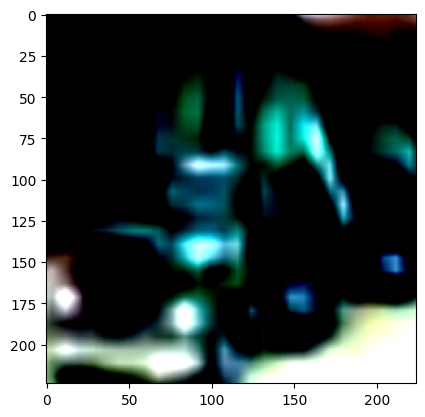

In [54]:
train_loader = DataLoader(data, batch_size =64, shuffle=True)
test_loader = DataLoader(test_data, batch_size = 64, shuffle=False)
for images, labels in train_loader:
    print(images.shape)  # torch.Size([64, 3, 32, 32])

    img = images[0].permute(1, 2, 0)  # (3,32,32) -> (32,32,3)

    plt.imshow(img)
    break

In [55]:
model = tmodels.resnet18(weights=weights) 
#basically weights=tmodels.ResNet18_Weights.DEFAULT -> pretrained  = True
model
# Everything before the final layer 
#       ↓ 
# Feature Extractor 

# Final Layer 

#       ↓ 

# Classifie

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
for p in model.parameters():
    p.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, 10)
device = "cuda" if torch.cuda.is_available() else "cpu"
device
model = model.to(device)
# for name, param in model.named_parameters():
#     print(name, param.requires_grad)

In [58]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

for epoch in range(3):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1, Loss: 0.6427
Epoch 2, Loss: 0.6318
Epoch 3, Loss: 0.6281


In [59]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 78.57%
